In [1]:
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import train_test_split
import pandas as pd

df = pd.read_csv("../data/processed/churn_processed.csv")

X = df.drop("Churn", axis=1)
y = df["Churn"]

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

In [2]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

lr = LogisticRegression(
    max_iter=5000,
    class_weight="balanced"
)

lr.fit(X_train_scaled, y_train)

pred = lr.predict(X_test_scaled)

print(classification_report(y_test, pred))

              precision    recall  f1-score   support

           0       0.90      0.72      0.80      1035
           1       0.51      0.78      0.61       374

    accuracy                           0.74      1409
   macro avg       0.70      0.75      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [3]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)

X_train_smote, y_train_smote = smote.fit_resample(
    X_train_scaled,
    y_train
)

print(y_train.value_counts())
print(y_train_smote.value_counts())


Churn
0    4139
1    1495
Name: count, dtype: int64
Churn
0    4139
1    4139
Name: count, dtype: int64


In [4]:
lr_smote = LogisticRegression(
    max_iter=5000
)

lr_smote.fit(
    X_train_smote,
    y_train_smote
)

pred_smote = lr_smote.predict(
    X_test_scaled
)

print(
    classification_report(
        y_test,
        pred_smote
    )
)


              precision    recall  f1-score   support

           0       0.91      0.72      0.80      1035
           1       0.50      0.80      0.62       374

    accuracy                           0.74      1409
   macro avg       0.71      0.76      0.71      1409
weighted avg       0.80      0.74      0.75      1409



In [5]:
probs = lr_smote.predict_proba(
    X_test_scaled
)[:,1]

In [6]:
import numpy as np

pred_40 = (probs > 0.40).astype(int)

print(
    classification_report(
        y_test,
        pred_40
    )
)

              precision    recall  f1-score   support

           0       0.93      0.64      0.76      1035
           1       0.46      0.87      0.61       374

    accuracy                           0.70      1409
   macro avg       0.70      0.75      0.68      1409
weighted avg       0.81      0.70      0.72      1409



In [7]:
pred_45 = (probs > 0.45).astype(int)

print(
    classification_report(
        y_test,
        pred_45
    )
)

              precision    recall  f1-score   support

           0       0.92      0.68      0.78      1035
           1       0.49      0.83      0.61       374

    accuracy                           0.72      1409
   macro avg       0.70      0.76      0.70      1409
weighted avg       0.80      0.72      0.74      1409



In [8]:
from sklearn.ensemble import RandomForestClassifier

rf_optimized = RandomForestClassifier(
    n_estimators=300,
    max_depth=10,
    min_samples_split=5,
    class_weight='balanced',
    random_state=42
)

rf_optimized.fit(X_train, y_train)

rf_pred = rf_optimized.predict(X_test)

In [9]:
from sklearn.metrics import classification_report

print(classification_report(
    y_test,
    rf_pred
))


              precision    recall  f1-score   support

           0       0.89      0.77      0.83      1035
           1       0.54      0.74      0.63       374

    accuracy                           0.77      1409
   macro avg       0.72      0.76      0.73      1409
weighted avg       0.80      0.77      0.77      1409



In [10]:
import pandas as pd

comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Balanced Logistic Regression",
        "Random Forest",
        "XGBoost",
        "Optimized Random Forest"
    ],
    "Accuracy": [0.80, 0.74, 0.79, 0.78, 0.77],
    "Recall": [0.55, 0.79, 0.49, 0.53, 0.74],
    "F1 Score": [0.60, 0.62, 0.56, 0.57, 0.63]
})

comparison

,Model,Accuracy,Recall,F1 Score
0,Logistic Regression,0.80,0.55,0.60
1,Balanced Logistic Regression,0.74,0.79,0.62
2,Random Forest,0.79,0.49,0.56
3,XGBoost,0.78,0.53,0.57
4,Optimized Random Forest,0.77,0.74,0.63


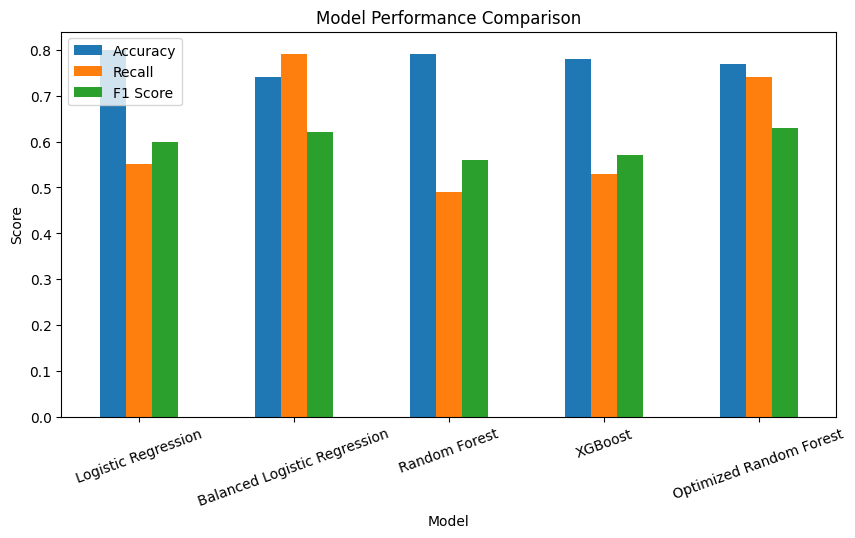

In [14]:
import matplotlib.pyplot as plt

comparison.set_index("Model")[["Accuracy","Recall","F1 Score"]].plot(
    kind="bar",
    figsize=(10,5)
)

plt.title("Model Performance Comparison")
plt.ylabel("Score")
plt.xticks(rotation=20)
plt.legend(loc="best")
plt.show()

### Model Optimization Summary:
* Applied feature scaling and SMOTE to address class imbalance.
* Evaluated threshold tuning to improve churn recall.
* Tuned Random Forest using class weights and optimized hyperparameters.
* The optimized Random Forest achieved the best balance between accuracy and churn detection performance